# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [8]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")

In [9]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.9.2
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [11]:
!pip install fastparquet

In [14]:
# Try loading one file
from pathlib import Path
parent = Path.cwd().parent

data_path = f"{parent}/data_NYC_Taxi/"
trip_records_path = f"{data_path}/trip_records"

# saving location for zones for later use.
taxi_zones_path = f"{data_path}/taxi_zones"

df = pd.read_parquet(f"{trip_records_path}/2023-1.parquet")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# Since I'm using jupyter notebook not google colab, this step isn't necessary.

In [15]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir(trip_records_path)

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe
df = pd.DataFrame()


# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_df = pd.read_parquet(file_path)

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date

        for date in month_df['tpep_pickup_datetime'].dt.date.unique():
          date_df = month_df[month_df['tpep_pickup_datetime'].dt.date == date]

          # Iterate through each hour of the selected date
          for hour in range(24):
            hour_df = date_df[date_df['tpep_pickup_datetime'].dt.hour == hour]
            sample = pd.DataFrame()
              
            # Sample 5% of the hourly data randomly
            # 5 % gives around 18 lac records so reducing the sampling rate to .007 
            # to get between 2.5 - 3 lac records.
            sample = hour_df.sample(frac = 0.007, random_state = 42)

            # add data of this hour to the dataframe
            sampled_data = pd.concat([sampled_data, sample])

        # Concatenate the sampled data of all the dates to a single dataframe
        df = pd.concat([df, sampled_data])# we initialised this empty DF earlier

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [16]:
# Store the df in csv/parquet
df.to_parquet('sampled_trip_records.parquet')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [17]:
# Load the new data file

df = pd.read_parquet('sampled_trip_records.parquet')

In [18]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
index,,,,,,,,,,,,,,,,,,,,
1788,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,23.30,1.0,0.5,5.66,0.0,1.0,33.96,2.5,0.0,NaN
3196699,2,2023-12-01 00:38:48,2023-12-01 01:01:55,NaN,4.79,NaN,None,231,61,0,22.43,0.0,0.5,3.00,0.0,1.0,29.43,NaN,NaN,NaN
1408,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,10.70,1.0,0.5,3.14,0.0,1.0,18.84,2.5,0.0,NaN
3196663,2,2023-12-01 00:00:50,2023-12-01 00:14:37,NaN,2.08,NaN,None,137,144,0,17.22,0.0,0.5,0.00,0.0,1.0,21.22,NaN,NaN,NaN
3613,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,5.10,1.0,0.5,0.00,0.0,1.0,10.10,2.5,0.0,NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 265495 entries, 1788 to 3207111
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               265495 non-null  int64         
 1   tpep_pickup_datetime   265495 non-null  datetime64[us]
 2   tpep_dropoff_datetime  265495 non-null  datetime64[us]
 3   passenger_count        256663 non-null  float64       
 4   trip_distance          265495 non-null  float64       
 5   RatecodeID             256663 non-null  float64       
 6   store_and_fwd_flag     256663 non-null  object        
 7   PULocationID           265495 non-null  int64         
 8   DOLocationID           265495 non-null  int64         
 9   payment_type           265495 non-null  int64         
 10  fare_amount            265495 non-null  float64       
 11  extra                  265495 non-null  float64       
 12  mta_tax                265495 non-null  float

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [20]:
# Fix the index and drop any columns that are not needed
df.reset_index(drop = True, inplace = True)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [21]:
# Combine the two airport fee columns
df['Airport_fee'] = df['Airport_fee'].fillna(df['airport_fee'])
df = df.drop('airport_fee', axis = 1)

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [22]:
# check where values of fare amount are negative
df[df['fare_amount'] < 0] 

# Observation : There are no entries with negative fare amount.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [23]:
# Analyse RatecodeID for the negative fare amounts
df[df['fare_amount'] < 0]['RatecodeID'].value_counts()

# Observation : There are no negative fare amounts.


Series([], Name: count, dtype: int64)

In [24]:
df['RatecodeID'].unique()

# Observation : the RateCodeID does have a lot of null values and 
# entries with value of 99 which is not mentioned in data dictionary.

array([ 1., nan,  5., 99.,  2.,  4.,  3.])

In [25]:
# Find which columns have negative values

numeric_df = df.select_dtypes(include=['number'])
columns_with_negatives = numeric_df.columns[(numeric_df < 0).any(axis=0)]
columns_with_negatives

Index(['extra', 'mta_tax', 'improvement_surcharge', 'total_amount',
       'congestion_surcharge', 'Airport_fee'],
      dtype='object')

In [26]:
# count of negative entries in the columns

negative_counts = (numeric_df < 0).sum()
negative_counts = negative_counts[negative_counts > 0]

print("Count of negative values per column:")
print(negative_counts)

Count of negative values per column:
extra                     1
mta_tax                  11
improvement_surcharge    11
total_amount             11
congestion_surcharge      6
Airport_fee               2
dtype: int64


In [27]:
# fix these negative values

# Action : Replacing the negative values with 0
df[columns_with_negatives] = df[columns_with_negatives].mask(df[columns_with_negatives] < 0, 0)


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [28]:
# Find the proportion of missing values in each column
df.isnull().mean() * 100


VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          3.326616
trip_distance            0.000000
RatecodeID               3.326616
store_and_fwd_flag       3.326616
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     3.326616
Airport_fee              3.326616
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [29]:
# Display the rows with null values
df[df.isnull().any(axis=1)]


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
1,2,2023-12-01 00:38:48,2023-12-01 01:01:55,NaN,4.79,NaN,None,231,61,0,22.43,0.0,0.5,3.00,0.0,1.0,29.43,NaN,NaN
3,2,2023-12-01 00:00:50,2023-12-01 00:14:37,NaN,2.08,NaN,None,137,144,0,17.22,0.0,0.5,0.00,0.0,1.0,21.22,NaN,NaN
27,2,2023-12-01 00:01:11,2023-12-01 00:15:53,NaN,3.49,NaN,None,164,262,0,17.83,0.0,0.5,0.00,0.0,1.0,21.83,NaN,NaN
45,1,2023-12-01 02:37:41,2023-12-01 02:44:13,NaN,0.00,NaN,None,186,48,0,7.43,0.0,0.5,0.00,0.0,1.0,11.43,NaN,NaN
47,2,2023-12-01 02:42:47,2023-12-01 03:03:24,NaN,8.09,NaN,None,246,116,0,42.06,0.0,0.5,0.00,0.0,1.0,46.06,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265220,2,2023-06-30 16:29:00,2023-06-30 16:55:00,NaN,4.55,NaN,None,142,79,0,28.24,0.0,0.5,10.00,0.0,1.0,42.24,NaN,NaN
265249,1,2023-06-30 17:41:43,2023-06-30 17:57:40,NaN,0.00,NaN,None,163,246,0,20.45,0.0,0.5,0.00,0.0,1.0,24.45,NaN,NaN
265300,2,2023-06-30 18:46:16,2023-06-30 19:01:57,NaN,3.86,NaN,None,36,260,0,17.55,0.0,0.5,3.81,0.0,1.0,22.86,NaN,NaN
265432,2,2023-06-30 22:12:06,2023-06-30 22:22:23,NaN,2.39,NaN,None,245,206,0,12.59,0.0,0.5,0.00,0.0,1.0,14.09,NaN,NaN


In [30]:
# Impute NaN values in 'passenger_count'
# Action : filling with median since it is giving the most frequent value.
# mean would give value 1.36 
# and that can't be a valid value for passenger_count.

median_pc = df['passenger_count'].median()
df['passenger_count'] = df['passenger_count'].fillna(median_pc)

Did you find zeroes in passenger_count? Handle these.

In [31]:
df['passenger_count'] = df['passenger_count'].replace(0, median_pc)

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [32]:
# Fix missing values in 'RatecodeID'

# Action : Since RatecodeID is a categorical column,
# fill the null values with the mode(most common value).

mode_ratecodeID = df['RatecodeID'].mode()[0]
df['RatecodeID'] = df['RatecodeID'].fillna(mode_ratecodeID)


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [33]:
# handle null values in congestion_surcharge

median_cs = df['congestion_surcharge'].median()
df['congestion_surcharge'] = df['congestion_surcharge'].fillna(median_cs)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [34]:
# Handle any remaining missing values

# Handle missing values in store_and_fwd_flag

# Since 'store_and_fwd_flag' is a categorical column,
# fill the null values with mode.
mode_storefwdflag = df['store_and_fwd_flag'].mode()[0]
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna(mode_storefwdflag)


In [35]:
# Handle missing values in Airport_fee

# This feature contains values [0.  ,  nan, 1.75, 1.25],
# So imputing null values with median will be sufficient.

median_airport_fee = df['Airport_fee'].median()
df['Airport_fee'] = df['Airport_fee'].fillna(median_airport_fee)

### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [36]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

df.describe()

# Observations:
# passenger_count has a max of 9, seems like data-entry error.
# trip_distance having entries as 0 and 22528.82
# ratecode id having value 99
# payment type 0

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,265495.000000,265495,265495,265495.000000,265495.000000,265495.000000,265495.000000,265495.000000,265495.000000,265495.00000,265495.000000,265495.000000,265495.000000,265495.000000,265495.000000,265495.000000,265495.000000,265495.000000
mean,1.733471,2023-07-02 20:33:51.990365,2023-07-02 20:51:13.697716,1.370527,3.581749,1.636471,165.173555,163.954779,1.164971,19.82994,1.587734,0.495346,3.548452,0.593706,0.999045,28.891795,2.314328,0.138272
min,1.000000,2023-01-01 00:04:34,2023-01-01 00:17:32,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,2023-04-02 16:36:06,2023-04-02 16:58:59.500000,1.000000,1.050000,1.000000,132.000000,113.000000,1.000000,9.30000,0.000000,0.500000,1.000000,0.000000,1.000000,15.960000,2.500000,0.000000
50%,2.000000,2023-06-27 16:01:53,2023-06-27 16:18:30,1.000000,1.800000,1.000000,162.000000,162.000000,1.000000,13.50000,1.000000,0.500000,2.840000,0.000000,1.000000,21.030000,2.500000,0.000000
75%,2.000000,2023-10-06 20:13:09.500000,2023-10-06 20:32:05.500000,1.000000,3.400000,1.000000,234.000000,234.000000,1.000000,21.90000,2.500000,0.500000,4.420000,0.000000,1.000000,30.800000,2.500000,0.000000
max,6.000000,2023-12-31 23:54:03,2024-01-01 20:14:57,9.000000,22528.820000,99.000000,265.000000,265.000000,4.000000,910.00000,14.250000,0.800000,150.290000,143.000000,1.000000,911.000000,2.500000,1.750000
std,0.447563,NaN,NaN,0.862981,48.595161,7.422640,64.070024,69.779760,0.506645,18.20476,1.824932,0.048095,4.046041,2.178506,0.028522,22.769055,0.655521,0.457663


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [37]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6]

In [38]:
# Continue with outlier handling

# Remove the entries where trip_distance is nearly 0 and fare_amount is more than 300
df = df[~((df['trip_distance'] <= 0.1) & (df['fare_amount'] > 300))]

# Remove the entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones
# are different (both distance and fare should not be zero for different zones)
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))]

# Remove the entries where trip_distance is more than 250 miles.
df = df[~(df['trip_distance'] > 250)]

# Remove the entries where payment_type is 0 (there is no payment_type 0 defined in the data dictionary)
df = df[~(df['payment_type'] == 0)]

# Remove the entries where RatecodeID is 99 (there is no RatecodeID 99 defined in the data dictionary)
df = df[~(df['RatecodeID'] == 99)]

In [303]:
# Do any columns need standardising?

# Standardization is done on numerical columns with continuous data so
# that data is at same scale for further analysis.

# Action - I've decided not to do standardize as in section 3.2.11, 3.2.12 we need average miles per hour.
# For that Actual data (trip distance)is needed to make groups like 0-2 miles, 2-5 miles.
# This isn't possible if we have standard values because 
# then all values are in 0-1 range.

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [39]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'Airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`: Numerical
* `tpep_dropoff_datetime`: Numerical
* `passenger_count`: Numerical (Discrete)
* `trip_distance`: Numerical
* `RatecodeID`: Categorical
* `PULocationID`: Numerical
* `DOLocationID`: Numerical
* `payment_type`: Categorical
* `pickup_hour`: Don't have this column
* `trip_duration`: Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?

Ans : Numerical.
But few columns don't have a wide range of values like Airport_fee,
congestion_surcharge so these are Discrete Numerical.


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

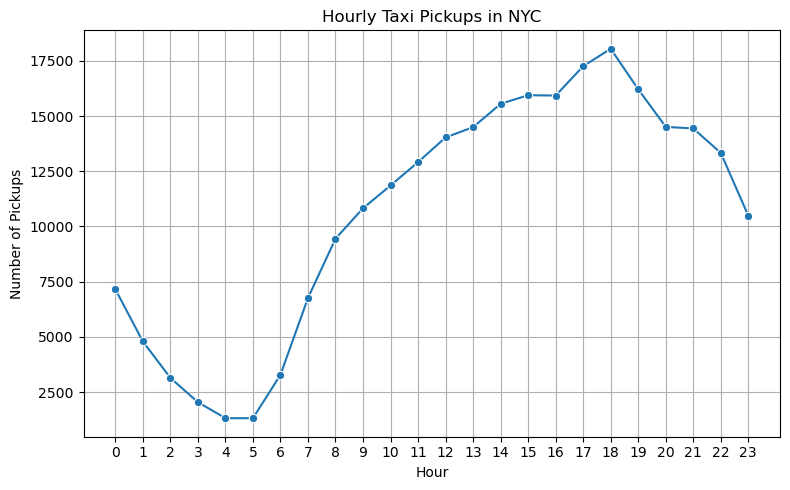

In [40]:
# Find and show the hourly trends in taxi pickups

df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

hourly_pickup_trend = df.groupby('pickup_hour')['pickup_hour'].count().reset_index(name='pickup_count')

plt.figure(figsize=(8, 5))
sns.lineplot(data = hourly_pickup_trend, x = 'pickup_hour', y = 'pickup_count', marker = 'o')
plt.title('Hourly Taxi Pickups in NYC')
plt.xlabel('Hour')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()

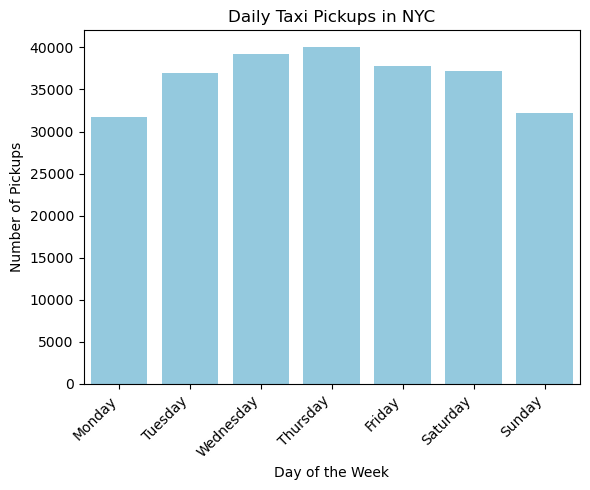

In [76]:
# Find and show the daily trends in taxi pickups (days of the week)

df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
daily_pickup_trend = df.groupby('pickup_day')['pickup_day'].count()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_pickup_trend = daily_pickup_trend.reindex(day_order)

plt.figure(figsize=(6, 5))
sns.barplot(x = daily_pickup_trend.index, y = daily_pickup_trend.values, color = 'skyblue')
plt.title('Daily Taxi Pickups in NYC')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

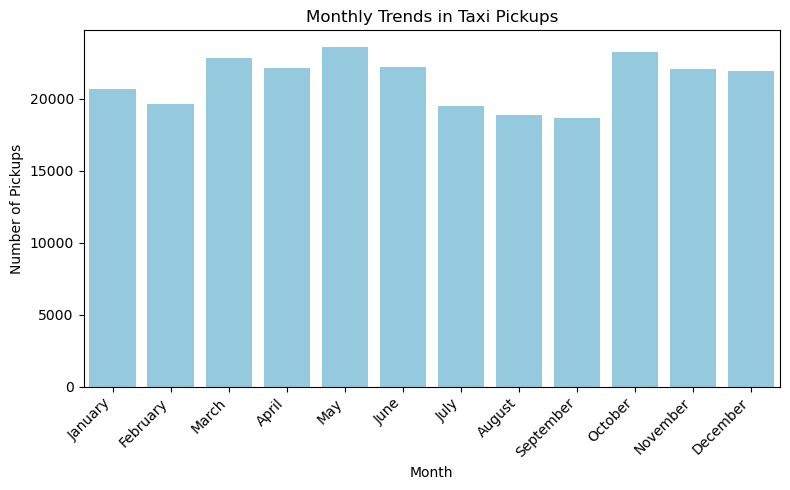

In [41]:
# Show the monthly trends in pickups

df['pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
monthly_pickups = df.groupby('pickup_month')['pickup_month'].count()
months_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_pickups = monthly_pickups.reindex(months_order)

plt.figure(figsize=(8, 5))
sns.barplot(x = monthly_pickups.index, y = monthly_pickups.values, color = 'skyblue')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.title('Monthly Trends in Taxi Pickups')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [42]:
# Analyse the above parameters

cols_to_check = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

zero_counts = (df[cols_to_check] == 0).sum()
negative_counts = (df[cols_to_check] < 0).sum()

analysis_df = pd.DataFrame({
        'zero_count': zero_counts,
        'negative_count': negative_counts
    })
analysis_df

,zero_count,negative_count
fare_amount,83,0
tip_amount,55871,0
total_amount,39,0
trip_distance,3017,0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [43]:
# Create a df with non zero entries for the selected parameters.

# Regarding the note above, there are approx 2054 entries with trip_distance as 0 having same
# pickup and drop-off location and non-zero fare_amount. These comes out to be 0.8 % of total entries.
# Since its not a high number, we can drop these entries.
df[((df['trip_distance'] == 0) & (df['fare_amount'] != 0) & (df['PULocationID'] == df['DOLocationID']))] # results in 2054 rows

filtered_df = df.copy()

filtered_df = filtered_df[
    (filtered_df['fare_amount'] != 0) &
    (filtered_df['tip_amount'] != 0) &
    (filtered_df['total_amount'] != 0) &
    (filtered_df['trip_distance'] != 0)
]
print(f"Original shape: {df.shape}")
print(f"Filtered shape: {filtered_df.shape}")

Original shape: (255120, 21)
Filtered shape: (198061, 21)


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

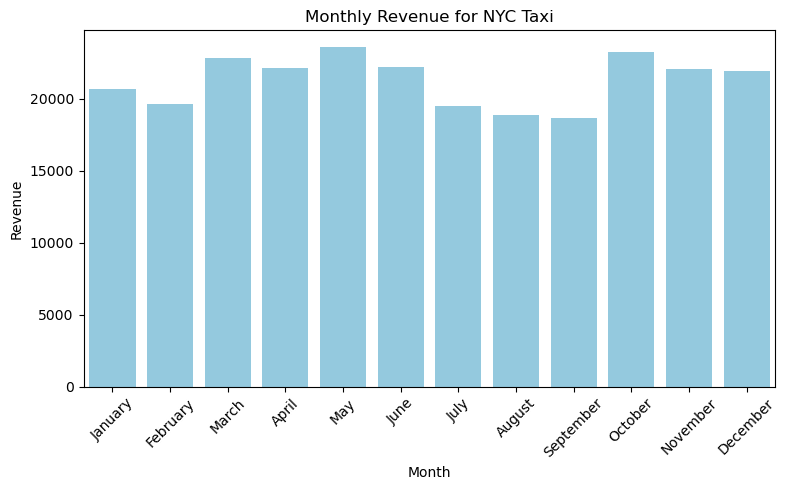

In [44]:
# Group data by month and analyse monthly revenue

monthly_revenue = df.groupby('pickup_month')['total_amount'].count()
monthly_revenue = monthly_revenue.reindex(months_order) # months_order previously defined in 3.1.2 months plot.

plt.figure(figsize=(8, 5))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, color = 'skyblue')
plt.title('Monthly Revenue for NYC Taxi')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [45]:
# Calculate proportion of each quarter

df['pickup_quarter'] = df['tpep_pickup_datetime'].dt.to_period('Q')
quarterly_revenue = df.groupby('pickup_quarter')['total_amount'].sum()
quarterly_revenue_proportion = (quarterly_revenue / quarterly_revenue.sum()) * 100
quarterly_revenue_proportion.round(2)

pickup_quarter
2023Q1    23.75
2023Q2    26.80
2023Q3    22.73
2023Q4    26.72
Freq: Q-DEC, Name: total_amount, dtype: float64

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

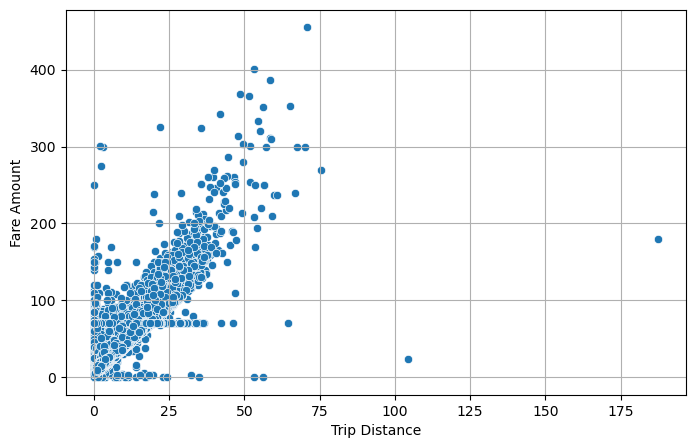

Correlation between trip_distance(non-zero) and fare_amount : 0.94


In [46]:
# Show how trip fare is affected by distance

# Since both are numerical columns, scatterplot would better show the relation.

filtered_df = df[df['trip_distance'] > 0]

plt.figure(figsize=(8, 5))
sns.scatterplot(x = 'trip_distance', y = 'fare_amount', data = filtered_df)
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

correlation = filtered_df['trip_distance'].corr(filtered_df['fare_amount'])
print(f"Correlation between trip_distance(non-zero) and fare_amount : {correlation:.2f}")

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

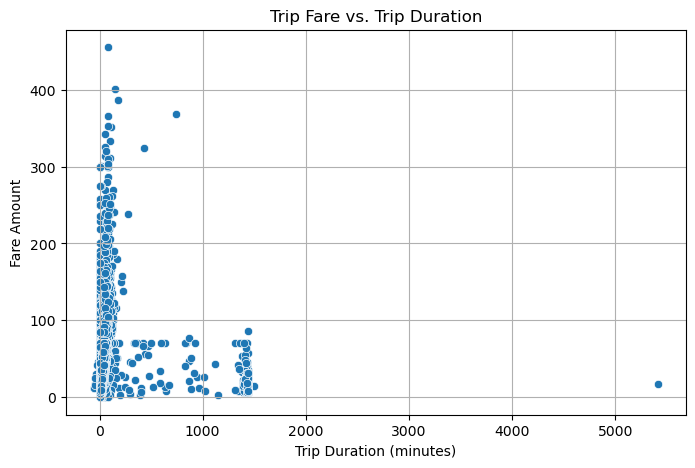

Correlation between trip duration and fare amount: 0.26


In [47]:
# Show relationship between fare and trip duration

df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

plt.figure(figsize=(8, 5))
sns.scatterplot(data = df, x = 'trip_duration', y = 'fare_amount')
plt.title('Trip Fare vs. Trip Duration')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount')
plt.grid(True)
plt.show()

correlation = df['trip_duration'].corr(df['fare_amount'])
print(f"Correlation between trip duration and fare amount: {correlation:.2f}")

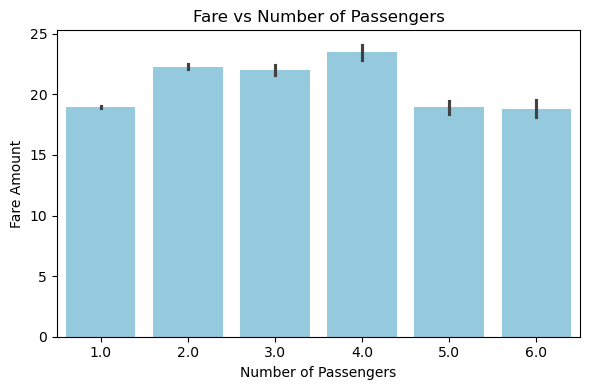

Correlation between number of passengers and fare amount: 0.05


In [49]:
# Show relationship between fare and number of passengers

plt.figure(figsize=(6, 4))
sns.barplot(data = df, x = 'passenger_count', y = 'fare_amount', color = 'skyblue')
plt.title('Fare vs Number of Passengers')
plt.xlabel('Number of Passengers')
plt.ylabel('Fare Amount')
plt.tight_layout()
plt.show()

correlation = df['passenger_count'].corr(df['fare_amount'])
print(f"Correlation between number of passengers and fare amount: {correlation:.2f}")

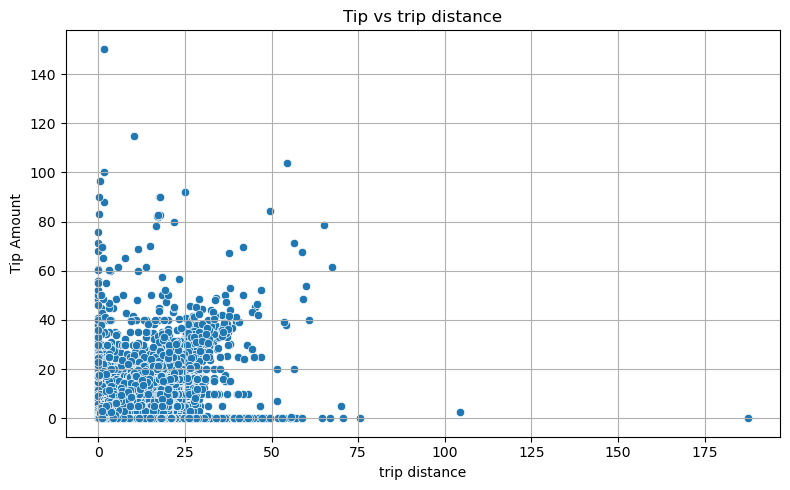

Correlation between tip amount and trip distance: 0.58


In [88]:
# Show relationship between tip and trip distance

plt.figure(figsize=(8, 5))
sns.scatterplot(data = df, x = 'trip_distance', y = 'tip_amount')
plt.title('Tip vs trip distance')
plt.xlabel('trip distance')
plt.ylabel('Tip Amount')
plt.grid(True)
plt.tight_layout()
plt.show()

correlation = df['tip_amount'].corr(df['trip_distance'])
print(f"Correlation between tip amount and trip distance: {correlation:.2f}")

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [50]:
# Analyse the distribution of different payment types (payment_type).

# percentage of usage among different payment types
df['payment_type'].value_counts(normalize = True) * 100


payment_type
1    81.350345
2    17.422781
4     0.748667
3     0.478206
Name: proportion, dtype: float64

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [51]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [56]:
import geopandas as gpd

taxi_zones_shpfile_path = f"{taxi_zones_path}/taxi_zones.shp"

# Read the shapefile using geopandas
zones = gpd.read_file(taxi_zones_shpfile_path)
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

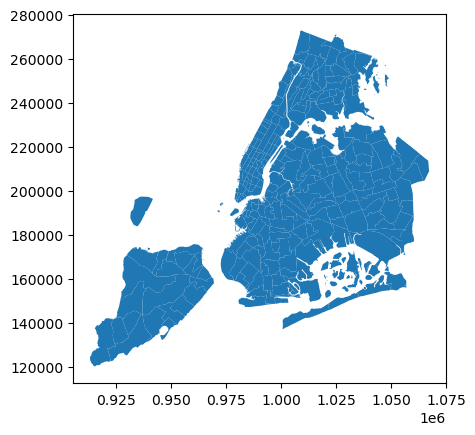

In [57]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [58]:
# Merge zones and trip records using locationID and PULocationID

merged_df = pd.merge(df, zones, left_on='PULocationID', right_on='LocationID', how='left')
merged_df.head()


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_month,pickup_quarter,trip_duration,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,2,2023-12-01 00:27:51,2023-12-01 00:50:12,1.0,3.99,1.0,N,148,50,1,...,December,2023Q4,22.350000,148.0,0.039131,0.000070,Lower East Side,148.0,Manhattan,"POLYGON ((988552.836 201677.665, 988387.669 20..."
1,2,2023-12-01 00:06:19,2023-12-01 00:16:57,1.0,1.05,1.0,N,161,161,1,...,December,2023Q4,10.633333,161.0,0.035804,0.000072,Midtown Center,161.0,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
2,2,2023-12-01 00:16:07,2023-12-01 00:19:17,1.0,0.40,1.0,N,68,68,1,...,December,2023Q4,3.166667,68.0,0.049337,0.000111,East Chelsea,68.0,Manhattan,"POLYGON ((983690.405 209040.369, 983550.612 20..."
3,2,2023-12-01 00:57:08,2023-12-01 01:05:49,1.0,1.66,1.0,N,114,186,1,...,December,2023Q4,8.683333,114.0,0.031727,0.000047,Greenwich Village South,114.0,Manhattan,"POLYGON ((986306.712 203122.786, 986300.242 20..."
4,2,2023-12-01 00:46:28,2023-12-01 00:59:29,2.0,2.45,1.0,N,164,232,1,...,December,2023Q4,13.016667,164.0,0.035772,0.000056,Midtown South,164.0,Manhattan,"POLYGON ((988787.425 210315.593, 988662.868 21..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [59]:
# Group data by location and calculate the number of trips

num_trips = df.groupby('PULocationID').size().reset_index(name='num_trips')
num_trips.head()

,PULocationID,num_trips
0,1,36
1,3,1
2,4,241
3,6,3
4,7,107


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [60]:
# Merge trip counts back to the zones GeoDataFrame

zones_with_trips = pd.merge(zones, num_trips, left_on='LocationID', right_on='PULocationID', how='left')
zones_with_trips.head()


,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,num_trips
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,36.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,1.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,241.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,NaN


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

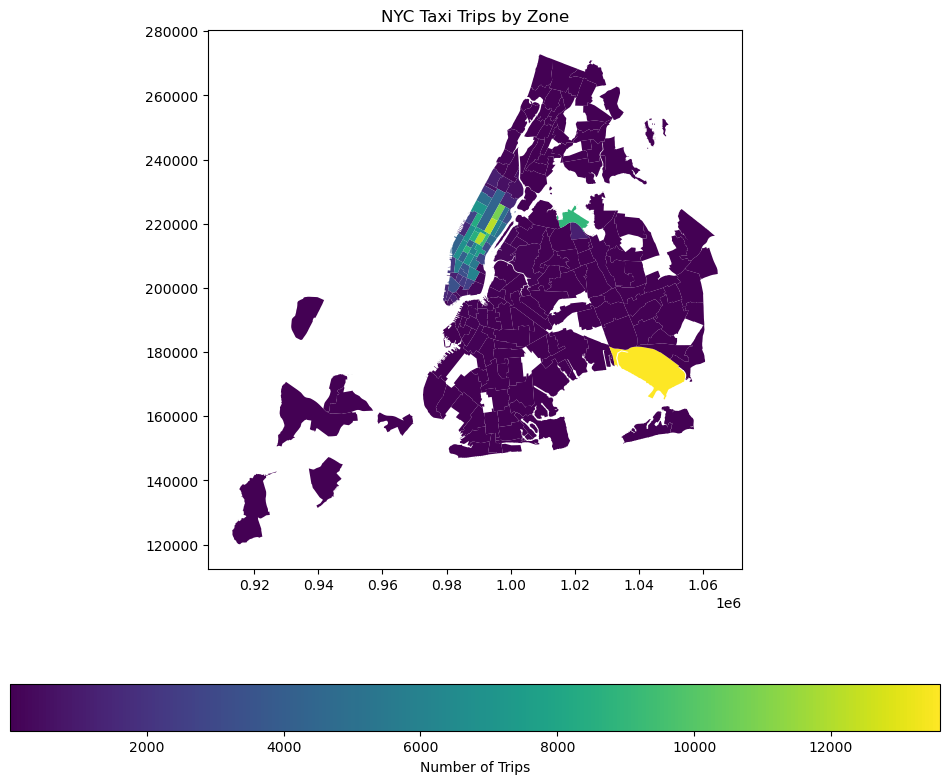

In [61]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it
zones_with_trips.plot(
    column = 'num_trips',
    ax = ax,
    legend = True,
    legend_kwds = {'label': "Number of Trips", 'orientation': "horizontal"}
)

ax.set_title("NYC Taxi Trips by Zone")
plt.show()


In [62]:
# can you try displaying the zones DF sorted by the number of trips?

zones_with_trips_sorted = zones_with_trips.sort_values(by='num_trips', ascending=False)
zones_with_trips_sorted.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,num_trips
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",132.0,13593.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",237.0,12118.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",161.0,12028.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",236.0,10797.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",162.0,9288.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones

**Findings**

**Busiest Hours**
Peak hours are the evening hours between 4pm-7pm.

**Busiest days**
These are  weekdays with mid-week(Thursday) being at the highest.
Monday and Sunday have lowest trip count.

**Busiest months**
March-June(probably financial year end) and holiday season(Oct-Dec) show highest trips.

**Revenue trends** 
These align with the busiest months, March-June and Oct-Dec being the highest grosser.

**Quarterly revenue trend**
As mentioned in above point, end of Q1(March), Q2(Apr-Jun) and Q4(Oct-Dec) are highest revenue earners.

**Fare vs trip distance, trip duration and passenger counts**
* Trip Distance: Fare increases roughly linearly with distance. These have a very strong correlation.
* Trip Duration: Shorter trips tend to have high fare, probably due to surcharges in busy areas.
* Passenger count: Fare doesn't fluctuate drastically depending on number of passenger in the trip.

**Tip Amount vs Trip Distance**
Tip amounts tend to increase with trip distance, but not proportionally.
We can see that shorter trips often get higher tip percentages, whereas longer trips may not always get higher tips.

**Busiest Zones**
'JFK' is the busiest zone due to high volume of airport passengers.
Followed by Upper East Side North and South which is a densely populated zone with affluent population.
And Midtown with its multiple tourist attractions.

#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [63]:
# Find routes which have the slowest speeds at different times of the day

df['trip_duration_hrs'] = (df['trip_duration']) / 60

# remove distance and hour-duration with 0 values or we get negative speeds
df_route = df[(df['trip_duration_hrs'] > 0) & (df['trip_distance'] > 0)]
speed_data = df_route.groupby(['PULocationID', 'DOLocationID', 'pickup_hour']).agg(
                    {'trip_distance': 'mean',
                     'trip_duration_hrs': 'mean'
                    }).reset_index()

speed_data['avg_speed'] = speed_data['trip_distance'] / speed_data['trip_duration_hrs']
slowest_routes = speed_data.sort_values(by='avg_speed').head(10)
print(slowest_routes[['PULocationID', 'DOLocationID', 'pickup_hour', 'avg_speed']])

       PULocationID  DOLocationID  pickup_hour  avg_speed
15288           113           113           13   0.025129
42834           226           145           18   0.026569
55934           260           129           17   0.040746
58720           264           237           15   0.043036
41469           209           232           13   0.043579
15831           113           235           22   0.048105
4797             50            43            8   0.059525
36745           164           100           21   0.067827
11036            88           144            0   0.074923
43261           229           137            2   0.081157


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

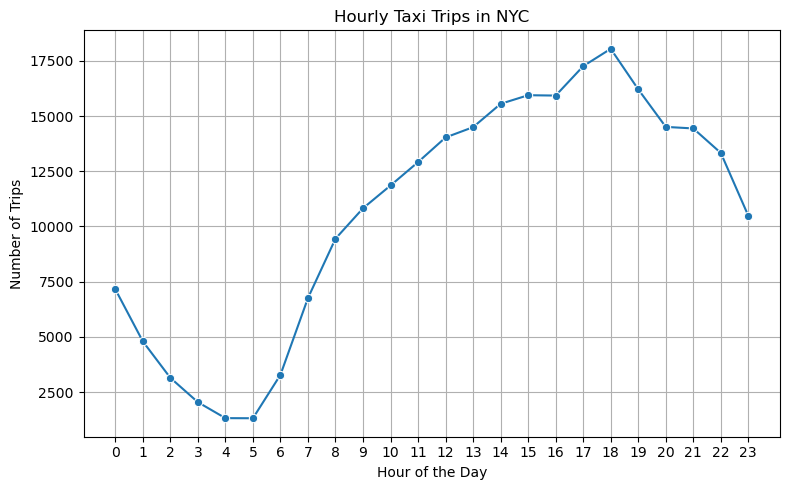

Busiest hour: 18
Number of trips during the busiest hour: 18048


In [64]:
# Visualise the number of trips per hour and find the busiest hour

# hourly_pickup_trend : Calculated in 3.1.2 We have done the similar visualization

busiest_hour = hourly_pickup_trend.loc[hourly_pickup_trend['pickup_count'].idxmax()]

plt.figure(figsize = (8, 5))
sns.lineplot(data = hourly_pickup_trend, x = 'pickup_hour', y = 'pickup_count', marker = 'o')
plt.title('Hourly Taxi Trips in NYC')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.xticks(range(0, 24))
plt.grid(True)
plt.tight_layout()
plt.show()


print(f"Busiest hour: {busiest_hour['pickup_hour']}")
print(f"Number of trips during the busiest hour: {busiest_hour['pickup_count']}")

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [90]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.007

trip_counts = df['pickup_hour'].value_counts().sort_index()

top5_hours = trip_counts.sort_values(ascending=False).head(5)
scaled_top5 = (top5_hours / sample_fraction).astype(int)
scaled_top5

pickup_hour
18    2578285
17    2466000
19    2316000
15    2278000
16    2275714
Name: count, dtype: int64

**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

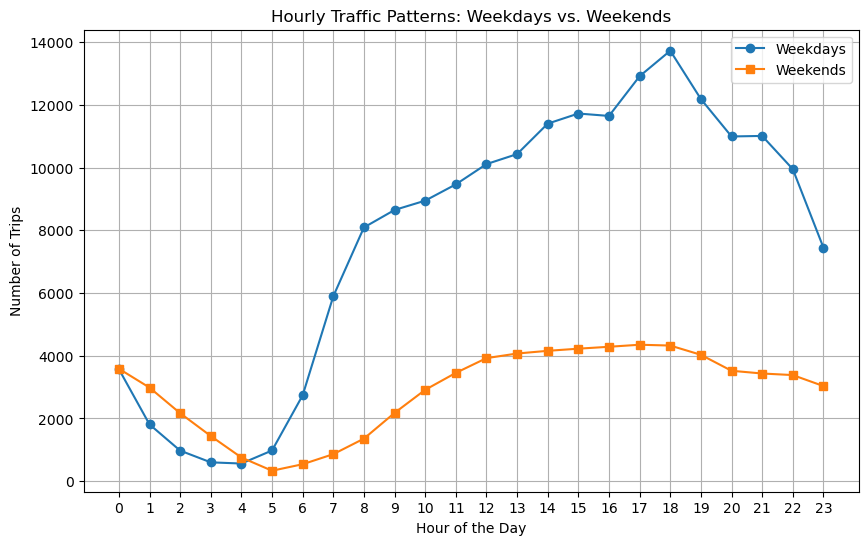

In [66]:
# Compare traffic trends for the week days and weekends

df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek
weekdays_df = df[df['pickup_day_of_week'] < 5]  # Monday to Friday
weekends_df = df[df['pickup_day_of_week'] >= 5]  # Saturday and Sunday
weekday_hourly_trips = weekdays_df.groupby(weekdays_df['pickup_hour'])['pickup_hour'].count()
weekend_hourly_trips = weekends_df.groupby(weekends_df['pickup_hour'])['pickup_hour'].count()

plt.figure(figsize=(10, 6))
plt.plot(weekday_hourly_trips.index, weekday_hourly_trips.values, label='Weekdays', marker='o')
plt.plot(weekend_hourly_trips.index, weekend_hourly_trips.values, label='Weekends', marker='s')
plt.title('Hourly Traffic Patterns: Weekdays vs. Weekends')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.xticks(range(24))
plt.legend()
plt.grid(True)
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [67]:
# Find top 10 pickup and dropoff zones

# Find top 10 pickup zones

hourly_zonal_pickups = df.groupby(['PULocationID', 'pickup_hour']).size().reset_index(name = 'pickup_count')

# Average pickups per hour per zone - find mean for the pickup counts for all hours of that zone.
avg_hourly_pickups = hourly_zonal_pickups.groupby('PULocationID')['pickup_count'].mean().reset_index()

# Sort and get top 10 locations
top_pickup_zones = avg_hourly_pickups.sort_values(by='pickup_count', ascending=False).head(10)

# Merge with zone names
top_pickup_zones = top_pickup_zones.merge(zones, left_on='PULocationID', right_on='LocationID')

top_pickup_zones[['PULocationID', 'zone', 'pickup_count']]


,PULocationID,zone,pickup_count
0,132,JFK Airport,566.375000
1,237,Upper East Side South,504.916667
2,161,Midtown Center,501.166667
3,236,Upper East Side North,449.875000
4,162,Midtown East,387.000000
5,138,LaGuardia Airport,373.750000
6,186,Penn Station/Madison Sq West,364.625000
7,230,Times Sq/Theatre District,356.958333
8,142,Lincoln Square East,348.166667
9,170,Murray Hill,315.000000


In [68]:
# Find top 10 dropoff zones

df['dropoff_hour'] = df['tpep_dropoff_datetime'].dt.hour

hourly_zonal_dropoffs = df.groupby(['DOLocationID', 'dropoff_hour']).size().reset_index(name = 'dropoff_count')

# Average dropoffs per hour per zone
avg_hourly_dropoffs = hourly_zonal_dropoffs.groupby('DOLocationID')['dropoff_count'].mean().reset_index()

# Sort and get top 10 locations
top_dropoff_zones = avg_hourly_dropoffs.sort_values(by='dropoff_count', ascending=False).head(10)

# Merge with zone names
top_dropoff_zones = top_dropoff_zones.merge(zones, left_on='DOLocationID', right_on='LocationID')

top_dropoff_zones[['DOLocationID', 'zone', 'dropoff_count']]

,DOLocationID,zone,dropoff_count
0,236,Upper East Side North,478.041667
1,237,Upper East Side South,447.958333
2,161,Midtown Center,417.583333
3,230,Times Sq/Theatre District,324.750000
4,170,Murray Hill,317.875000
5,162,Midtown East,304.583333
6,142,Lincoln Square East,302.583333
7,239,Upper West Side South,298.500000
8,141,Lenox Hill West,276.791667
9,68,East Chelsea,273.250000


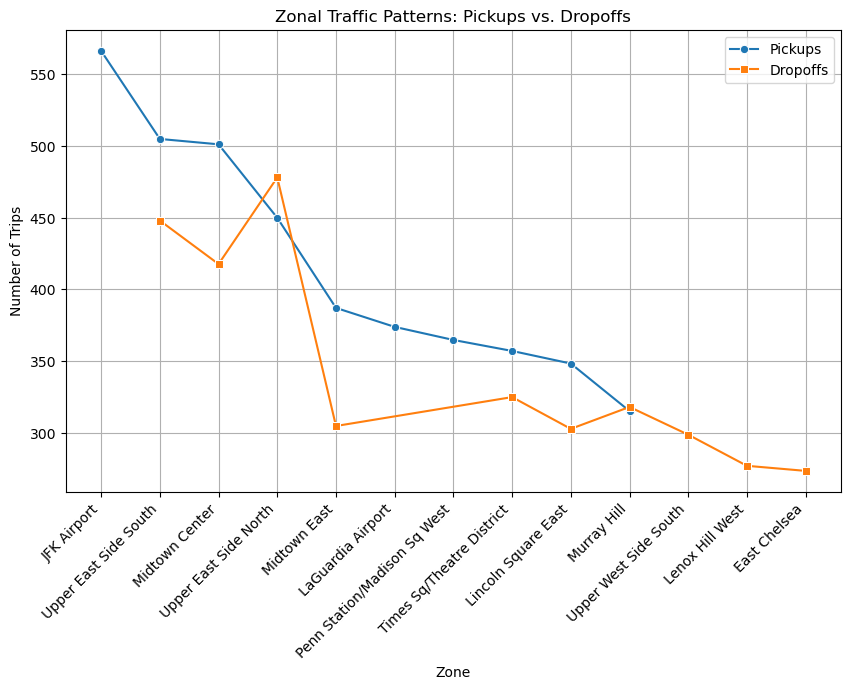

In [69]:
# Show pickup and dropoff trends in these zones.

plt.figure(figsize=(10, 6))
sns.lineplot(data = top_pickup_zones, x = 'zone', y='pickup_count', label='Pickups', marker='o')
sns.lineplot(data = top_dropoff_zones, x = 'zone', y = 'dropoff_count', label='Dropoffs', marker='s')
plt.title('Zonal Traffic Patterns: Pickups vs. Dropoffs')
plt.xlabel('Zone')
plt.ylabel('Number of Trips')
plt.legend()
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [70]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

pickup_counts = df['PULocationID'].value_counts().rename('pickup_count')
dropoff_counts = df['DOLocationID'].value_counts().rename('dropoff_count')

pu_do_ratios = pd.concat([pickup_counts, dropoff_counts], axis=1).fillna(0)
pu_do_ratios['pickup_dropoff_ratio'] = pu_do_ratios['pickup_count'] / pu_do_ratios['dropoff_count'].replace(0, np.nan)
pu_do_ratios = pu_do_ratios.reset_index().rename(columns={'index': 'LocationID'})
pu_do_ratios = pu_do_ratios.merge(zones[['LocationID', 'zone']], on='LocationID', how='left')
pu_do_ratios = pu_do_ratios.set_index('zone')
pickup_dropoff_ratios = pu_do_ratios['pickup_dropoff_ratio']

print("        Top Pickup-Dropoff Ratios")
top_pickup_dropoff_ratio = pickup_dropoff_ratios.sort_values(ascending=False).head(10)
top_pickup_dropoff_ratio


        Top Pickup-Dropoff Ratios


zone
East Elmhurst                   8.180556
JFK Airport                     4.709979
LaGuardia Airport               2.903852
Penn Station/Madison Sq West    1.515587
Central Park                    1.394469
West Village                    1.366110
Greenwich Village South         1.343662
Midtown East                    1.270588
Midtown Center                  1.200160
Garment District                1.189841
Name: pickup_dropoff_ratio, dtype: float64

In [71]:
print("  Bottom Pickup-Dropoff Ratios")
bottom_pickup_dropoff_ratio = pickup_dropoff_ratios.sort_values().head(10)
bottom_pickup_dropoff_ratio

  Bottom Pickup-Dropoff Ratios


zone
Mariners Harbor            0.0
Bronx Park                 0.0
Bath Beach                 0.0
Glen Oaks                  0.0
Hunts Point                0.0
Rockaway Park              0.0
Ozone Park                 0.0
Bay Terrace/Fort Totten    0.0
Highbridge                 0.0
Sunset Park East           0.0
Name: pickup_dropoff_ratio, dtype: float64

**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [72]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

merged_df['dropoff_hour'] = merged_df['tpep_dropoff_datetime'].dt.hour
night_trip_df = merged_df[(merged_df['pickup_hour'] >=23) | (merged_df['dropoff_hour'] <= 5)]

night_pickup_counts = (night_trip_df
                       .groupby(['PULocationID', 'zone'])
                       .size()
                       .reset_index(name='night_pickup_count')
                       .sort_values(by='night_pickup_count', ascending=False)
                       .head(10)
                      )

night_dropoff_counts = (night_trip_df
                       .groupby(['DOLocationID', 'zone'])
                       .size()
                       .reset_index(name='night_dropoff_count')
                       .sort_values(by='night_dropoff_count', ascending=False)
                       .head(10)
                      )

print(night_pickup_counts[['zone','night_pickup_count']].to_string(index=False))
print(night_dropoff_counts[['zone','night_dropoff_count']].to_string(index=False))


                        zone  night_pickup_count
                East Village                2186
                 JFK Airport                1973
                West Village                1774
                Clinton East                1424
             Lower East Side                1373
   Times Sq/Theatre District                1184
     Greenwich Village South                1182
Penn Station/Madison Sq West                 952
           LaGuardia Airport                 887
               Midtown South                 847
                     zone  night_dropoff_count
             East Village                  128
             East Village                  124
             East Village                  115
          Lower East Side                  113
             West Village                   98
             Clinton East                   92
              JFK Airport                   90
             East Village                   88
             East Village             

Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [73]:
# Filter for night hours (11 PM to 5 AM)

night_df = df[(df['pickup_hour'] >= 23) | (df['pickup_hour'] <= 5)]  # 11 PM - 5 AM
day_df = df[(df['pickup_hour'] >= 6) & (df['pickup_hour'] <= 22)]  # 6 AM - 10 PM

night_revenue = night_df['total_amount'].sum()
day_revenue = day_df['total_amount'].sum()

total_revenue = df['total_amount'].sum()

night_revenue_share = (night_revenue / total_revenue) * 100
day_revenue_share = (day_revenue / total_revenue) * 100

print(f"Nighttime Revenue Share: {night_revenue_share:.2f}%")
print(f"Daytime Revenue Share: {day_revenue_share:.2f}%")

Nighttime Revenue Share: 12.17%
Daytime Revenue Share: 87.83%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [74]:
# Analyse the fare per mile per passenger for different passenger counts

valid_trips_df = df[(df['trip_distance'] > 0) & (df['passenger_count'] > 0)]
valid_trips_df['fare_per_mile_per_passenger'] = valid_trips_df['total_amount'] / (valid_trips_df['trip_distance'] * valid_trips_df['passenger_count'])
avg_fare_per_mile_per_passenger = valid_trips_df.groupby('passenger_count')['fare_per_mile_per_passenger'].mean()
avg_fare_per_mile_per_passenger



passenger_count
1.0    16.549364
2.0     9.131572
3.0     6.190183
4.0     6.818431
5.0     2.610405
6.0     2.105198
Name: fare_per_mile_per_passenger, dtype: float64

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [79]:
# Compare the average fare per mile for different days and for different times of the day

valid_df = df[(df['trip_distance'] > 0) & (df['total_amount'] > 0)]

valid_df['fare_per_mile'] = valid_df['total_amount'] / valid_df['trip_distance']

avg_fare_by_day = valid_df.groupby('pickup_day')['fare_per_mile'].mean().round(2)

avg_fare_by_hour = valid_df.groupby('pickup_hour')['fare_per_mile'].mean().round(2)

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
avg_fare_by_day = avg_fare_by_day.reindex(days_order)
avg_fare_by_day

pickup_day
Monday       15.72
Tuesday      17.07
Wednesday    17.71
Thursday     19.24
Friday       15.63
Saturday     16.55
Sunday       16.88
Name: fare_per_mile, dtype: float64

In [80]:
avg_fare_by_hour

pickup_hour
0     17.08
1     21.42
2     14.49
3     14.96
4     28.86
5     17.04
6     19.12
7     13.27
8     15.04
9     15.24
10    15.78
11    16.40
12    17.24
13    18.30
14    17.90
15    15.87
16    21.02
17    18.81
18    17.26
19    18.88
20    15.11
21    14.22
22    17.29
23    14.71
Name: fare_per_mile, dtype: float64

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

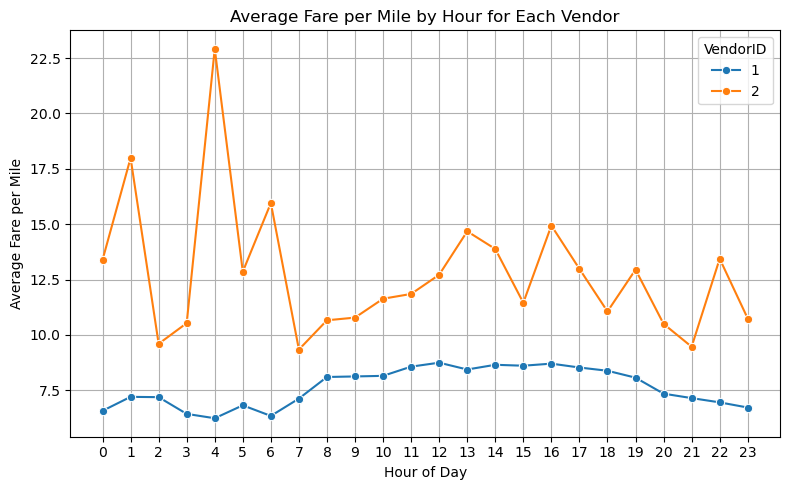

In [81]:
# Compare fare per mile for different vendors

valid_trips = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)]
valid_trips['fare_per_mile'] = valid_trips['fare_amount'] / valid_trips['trip_distance']

avg_fare_per_mile = (
    valid_trips
    .groupby(['VendorID', 'pickup_hour'])['fare_per_mile']
    .mean()
    .reset_index()
    .sort_values(by=['VendorID', 'pickup_hour'])
)

plt.figure(figsize=(8, 5))
sns.lineplot(data = avg_fare_per_mile, x='pickup_hour', y='fare_per_mile', hue='VendorID', marker='o', palette='tab10')
plt.title('Average Fare per Mile by Hour for Each Vendor')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare per Mile')
plt.grid(True)
plt.xticks(range(0, 24))
plt.legend(title = 'VendorID')
plt.tight_layout()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


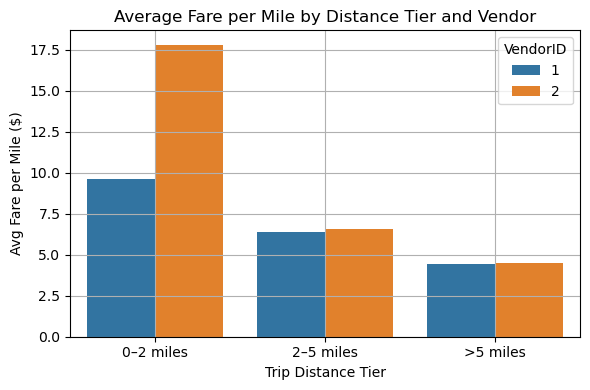

In [82]:
# Defining distance tiers

valid_trips = df[(df['trip_distance'] > 0) & (df['fare_amount'] > 0)].copy()
valid_trips['fare_per_mile'] = valid_trips['fare_amount'] / valid_trips['trip_distance']

# separate column for distance tiers
def distance_tier(dist):
    if dist <= 2:
        return '0–2 miles'
    elif dist <= 5:
        return '2–5 miles'
    else:
        return '>5 miles'

valid_trips['distance_tier'] = valid_trips['trip_distance'].apply(distance_tier)

tiered_fare_analysis = (
    valid_trips
    .groupby(['VendorID', 'distance_tier'])['fare_per_mile']
    .mean()
    .reset_index()
    .sort_values(by=['distance_tier', 'VendorID'])
)

tiered_fare_analysis

plt.figure(figsize=(6, 4))
sns.barplot(
    data=tiered_fare_analysis,
    x='distance_tier',
    y='fare_per_mile',
    hue='VendorID',
    palette='tab10'
)
plt.title('Average Fare per Mile by Distance Tier and Vendor')
plt.xlabel('Trip Distance Tier')
plt.ylabel('Avg Fare per Mile ($)')
plt.grid(True)
plt.tight_layout()
plt.legend(title='VendorID')
plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

Average Tip % by Distance Tier:
distance_tier   tip_pct
    0–2 miles 22.519983
    2–5 miles 18.815037
     >5 miles 16.865904

Average Tip % by Passenger Count:
 passenger_count   tip_pct
             1.0 20.862876
             2.0 19.719430
             3.0 19.018400
             4.0 17.453049
             5.0 20.812094
             6.0 20.714761

Average Tip % by Pickup Hour:
 pickup_hour   tip_pct
           0 20.648580
           1 21.283448
           2 20.296157
           3 20.713175
           4 17.930592
           5 17.858095
           6 19.910050
           7 19.869681
           8 20.209540
           9 19.848169
          10 19.434835
          11 19.238452
          12 19.397353
          13 19.179979
          14 19.254957
          15 18.959067
          16 21.248519
          17 21.768903
          18 22.242223
          19 22.209089
          20 21.324401
          21 21.575262
          22 21.690232
          23 20.591171


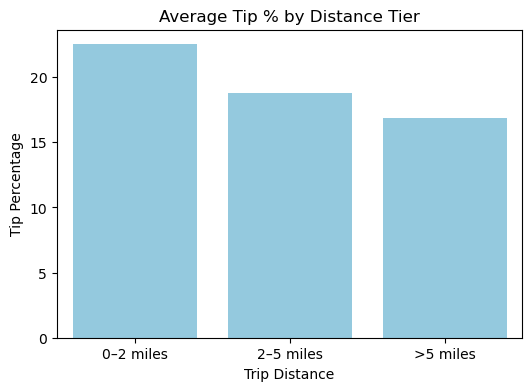

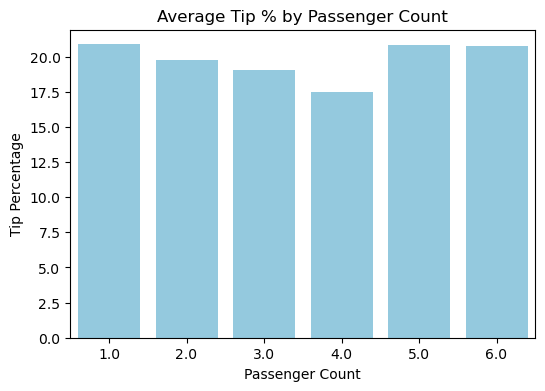

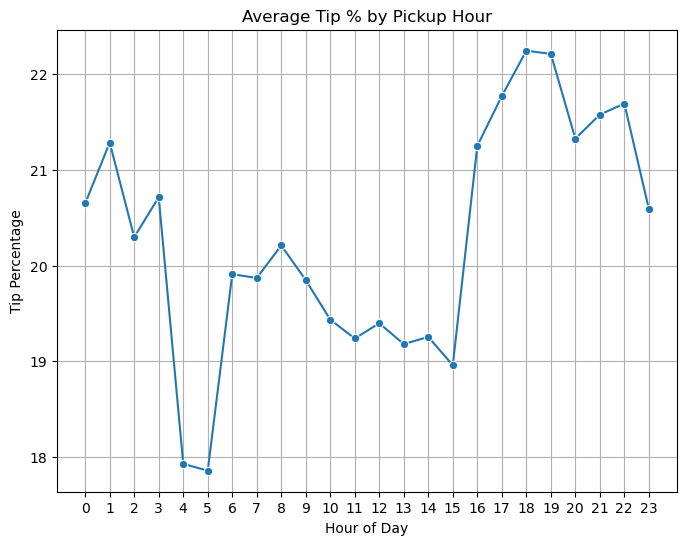

In [83]:
valid_df = df[
    (df['fare_amount'] > 0) &
    (df['trip_distance'] > 0) &
    (df['tip_amount'] >= 0)
].copy()

valid_df['tip_pct'] = (valid_df['tip_amount'] / valid_df['fare_amount']) * 100

valid_df['distance_tier'] = valid_df['trip_distance'].apply(distance_tier)

tip_by_distance = (
    valid_df.groupby('distance_tier')['tip_pct']
    .mean()
    .reset_index()
    .sort_values(by='tip_pct', ascending=False)
)

tip_by_passenger = (
    valid_df.groupby('passenger_count')['tip_pct']
    .mean()
    .reset_index()
    .sort_values(by='passenger_count')
)

tip_by_hour = (
    valid_df.groupby('pickup_hour')['tip_pct']
    .mean()
    .reset_index()
    .sort_values(by='pickup_hour')
)

print("Average Tip % by Distance Tier:")
print(tip_by_distance.to_string(index=False))

print("\nAverage Tip % by Passenger Count:")
print(tip_by_passenger.to_string(index=False))

print("\nAverage Tip % by Pickup Hour:")
print(tip_by_hour.to_string(index=False))

# Tip % by Distance Tier
plt.figure(figsize=(6, 4))
sns.barplot(data=tip_by_distance, x='distance_tier', y='tip_pct', color="skyblue")
plt.title('Average Tip % by Distance Tier')
plt.ylabel('Tip Percentage')
plt.xlabel('Trip Distance')
plt.show()

# Tip % by Passenger Count
plt.figure(figsize=(6, 4))
sns.barplot(data=tip_by_passenger, x='passenger_count', y='tip_pct', color="skyblue")
plt.title('Average Tip % by Passenger Count')
plt.ylabel('Tip Percentage')
plt.xlabel('Passenger Count')
plt.show()

# Tip % by Hour
plt.figure(figsize=(8, 6))
sns.lineplot(data=tip_by_hour, x='pickup_hour', y='tip_pct', marker='o')
plt.title('Average Tip % by Pickup Hour')
plt.ylabel('Tip Percentage')
plt.xlabel('Hour of Day')
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [348]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

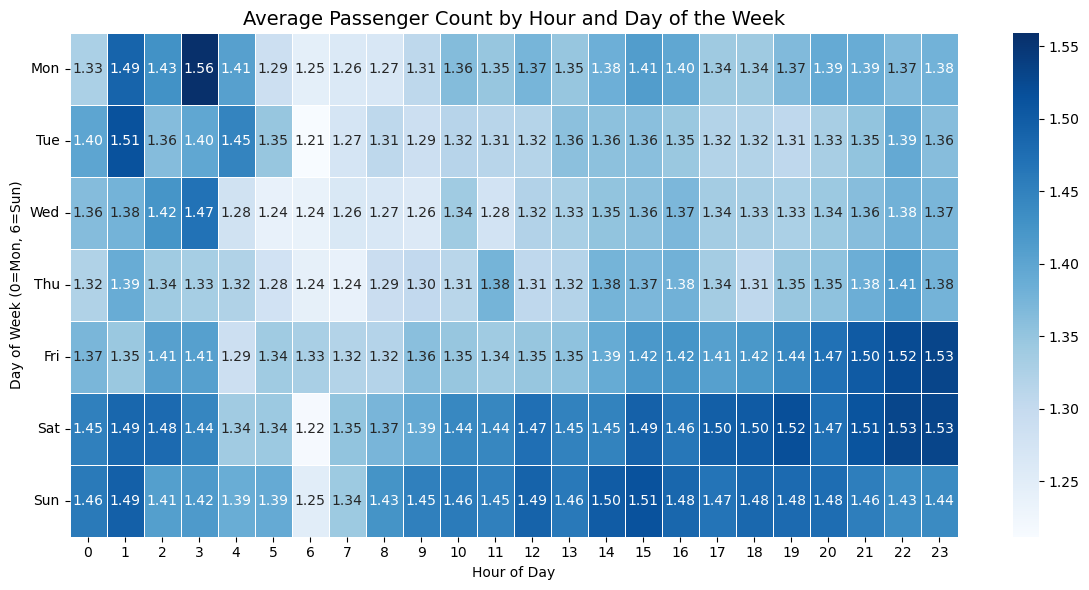

In [84]:
# See how passenger count varies across hours and days

passenger_variation = df.groupby(['pickup_day_of_week', 'pickup_hour'])['passenger_count'].mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(passenger_variation, cmap='Blues', linewidths=0.5, annot=True, fmt=".2f")
plt.title('Average Passenger Count by Hour and Day of the Week', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0=Mon, 6=Sun)')
plt.yticks(ticks=np.arange(7) + 0.5, labels=['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], rotation=0)
plt.tight_layout()
plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

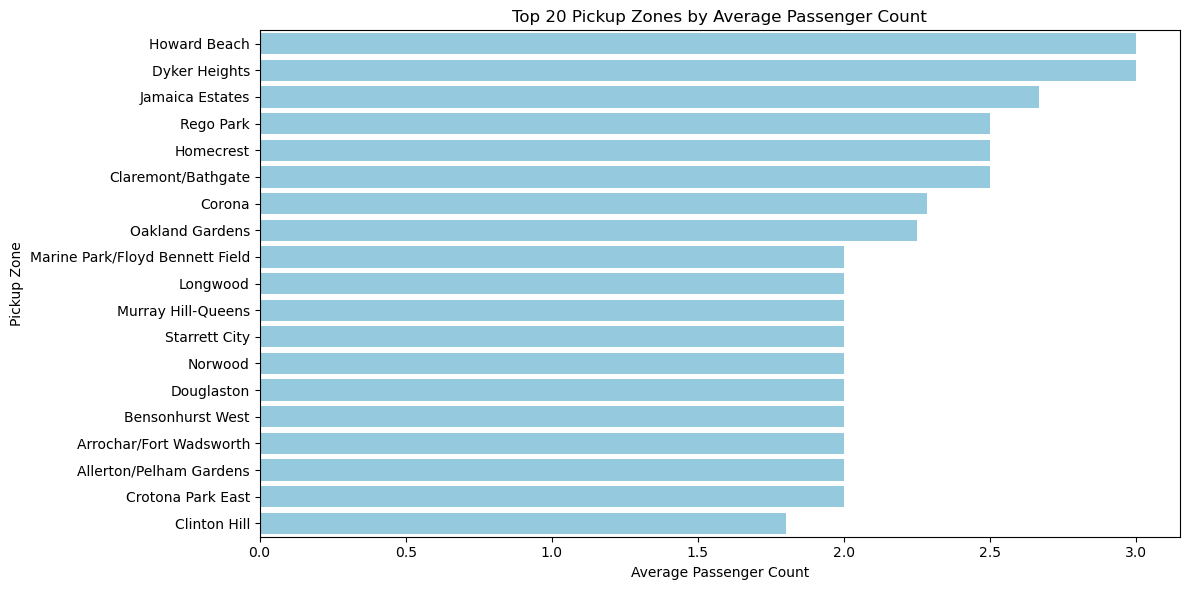

In [85]:
# How does passenger count vary across zones

zone_passenger_avg = df.groupby('PULocationID')['passenger_count'].mean().reset_index()

zone_passenger_avg = zone_passenger_avg.merge(zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')

zone_passenger_avg = zone_passenger_avg.sort_values(by='passenger_count', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=zone_passenger_avg, x='passenger_count', y='zone', color = 'skyblue')
plt.title('Top 20 Pickup Zones by Average Passenger Count')
plt.xlabel('Average Passenger Count')
plt.ylabel('Pickup Zone')
plt.tight_layout()
plt.show()

In [86]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.

avg_passenger_by_zone = df.groupby('PULocationID')['passenger_count'].mean().reset_index()
avg_passenger_by_zone.rename(columns={'passenger_count': 'avg_passenger_count'}, inplace=True)
zones_with_trips = zones_with_trips.merge(avg_passenger_by_zone, left_on='LocationID', right_on='PULocationID', how='left')
zones_with_trips.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID_x,num_trips,PULocationID_y,avg_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,36.0,1.0,1.666667
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN,NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,1.0,3.0,2.000000
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,241.0,4.0,1.377593
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,NaN,NaN,NaN


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

Frequency of Surcharge Application (%):
extra                    62.277360
mta_tax                  99.080041
tip_amount               78.100110
tolls_amount              8.018579
improvement_surcharge    99.965114
congestion_surcharge     92.874726
Airport_fee               8.859360
dtype: float64


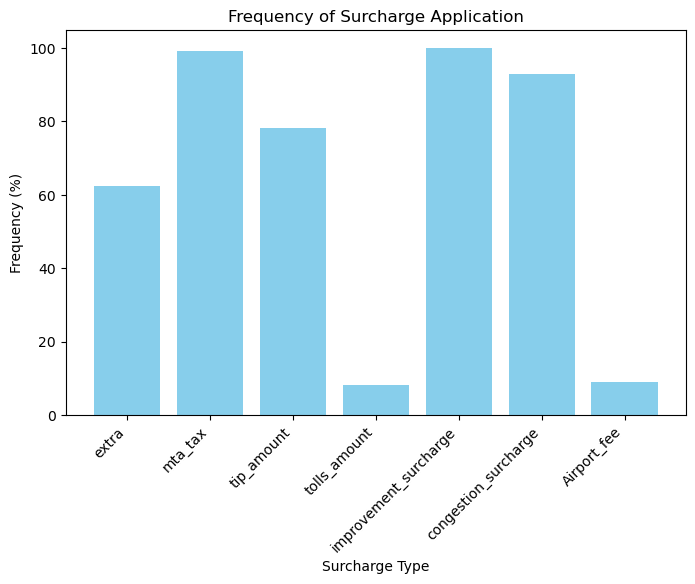

In [87]:
# How often is each surcharge applied?

surcharge_cols = ['extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'Airport_fee']

surcharge_frequency = df[surcharge_cols].astype(bool).sum() / len(df) * 100

print("Frequency of Surcharge Application (%):")
print(surcharge_frequency)

plt.figure(figsize=(8, 5))
plt.bar(surcharge_frequency.index, surcharge_frequency.values, color = 'skyblue')
plt.title('Frequency of Surcharge Application')
plt.xlabel('Surcharge Type')
plt.ylabel('Frequency (%)')
plt.xticks(rotation=45, ha='right')
#plt.grid(True)
plt.show()

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**Key Insights:**
- Temporal : Peak demand during rush hours, weekends, and specific months. Significant nighttime demand in nightlife zones.
- Financial: Fare correlated with distance and duration. Potential discounts for shared rides. Tip percentages influenced by trip characteristics.
- Geographical: High-demand zones include airports, hubs, and popular destinations. Pickup/dropoff imbalances in some zones. Nighttime hotspots for nightlife and entertainment.
- Vendor/Surcharges: Varying fare rates among vendors. Frequent application of certain surcharges. Tiered pricing based on distance.

**Suggestions:**

Demand and Supply

- Deploy more taxis in high-demand zones during peak periods.
- Enhance nighttime service in nightlife hotspots.
- Tailor services for group trips and shared rides.
- Consider dynamic pricing based on demand and trip characteristics.
- Encourage taxi repositioning to balance supply.
- Provide driver incentives for less busy periods or underserved zones.

Customer Experience:

- Ensure service quality through training and monitoring.
- Promote ride-sharing.

Continuous Improvement:

- Monitor operations and adapt strategies using data analysis and feedback.


**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**Strategic Cab Positioning:**

- **Time-Based:** Adjust cab deployment based on rush hours, nighttime demand, midday lulls, and monthly trends.
- **Day-Based:** Focus on business districts during weekdays and entertainment/residential areas during weekends. Adapt to special events.
- **Zone-Based:** Prioritize high-demand zones, address pickup/dropoff imbalances, and increase presence in nighttime hotspots.
- **Data-Driven:** Use real-time data, predictive models, and ride-hailing platforms for dynamic positioning.
- **Collaboration:** Communicate with drivers and partner with city officials for optimized operations.
- **Technology:** Leverage GPS tracking, heatmaps, and data analytics dashboards for strategic insights.

By implementing these strategies, taxi companies and drivers can optimize cab positioning to meet customer demand, minimize wait times, and enhance efficiency in NYC.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

**Data-Driven Pricing Adjustments:**

- **Dynamic Pricing:** Adjust fares based on real-time demand, supply, and traffic conditions. Increase during peak hours, offer discounts during off-peak times.
- **Tiered Pricing:** Maintain competitive rates for short trips, implement tiered pricing for longer distances, and consider zone-based variations.
- **Shared Rides:** Offer group discounts and shared ride options to maximize vehicle occupancy and cater to diverse passenger needs.
- **Surcharge Optimization:** Analyze surcharge frequency, implement peak surcharges when necessary, and maintain transparent communication with passengers.
- **Competitive Benchmarking:** Monitor competitor pricing, adjust accordingly, and highlight unique value propositions to justify premium pricing where applicable.
- **Continuous Monitoring:** Collect and analyze data, conduct A/B testing, and adapt pricing strategies dynamically to optimize revenue and customer satisfaction.

By implementing these data-driven adjustments, taxi companies can maximize revenue while remaining competitive and enhancing the overall taxi experience.